In [2]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [3]:
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)
num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.RKC9NI_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.RKC9NI_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [4]:
def scale(image,label):
  image = tf.cast(image, tf.float32)
  image /= 255.
  return image, label

scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)

In [5]:
BUFFER_SIZE = 1000
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

In [6]:
BATCH_SIZE = 100
train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)
validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape, validation_targets.shape)

(6000, 28, 28, 1) (6000,)


In [7]:
input_size = 784
output_size = 10

hidden_layer_size = 50

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(output_size, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
NUM_EPOCHS = 30
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)
model.fit(train_data,
          epochs=NUM_EPOCHS,
          callbacks=[early_stopping],
          validation_data=(validation_inputs, validation_targets),
          verbose= 1
          )

Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8836 - loss: 0.4057 - val_accuracy: 0.9380 - val_loss: 0.2224
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9448 - loss: 0.1887 - val_accuracy: 0.9495 - val_loss: 0.1748
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9572 - loss: 0.1458 - val_accuracy: 0.9523 - val_loss: 0.1540
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9646 - loss: 0.1201 - val_accuracy: 0.9567 - val_loss: 0.1398
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9697 - loss: 0.1012 - val_accuracy: 0.9583 - val_loss: 0.1352
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9743 - loss: 0.0874 - val_accuracy: 0.9590 - val_loss: 0.1334
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9768 - loss: 0.0764 - val_accuracy: 0.9647 - val_loss: 0.1245
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9797 - loss: 0.0666 - val_accuracy: 

In [9]:
test_loss, test_accuracy = model.evaluate(test_data)
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9689 - loss: 0.1069
Test loss: 0.11. Test accuracy: 96.89%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

Tablica prawdopodobieństw:
[[5.9212779e-24 1.2326755e-14 2.0939720e-16 1.0000000e+00 7.8201773e-34
  5.6893330e-17 7.2957718e-34 1.2951965e-24 3.0380967e-18 5.3127375e-18]]
Sieć neuronowa wykryła następującą cyfrę: 3 (Pewność: 100.00%)


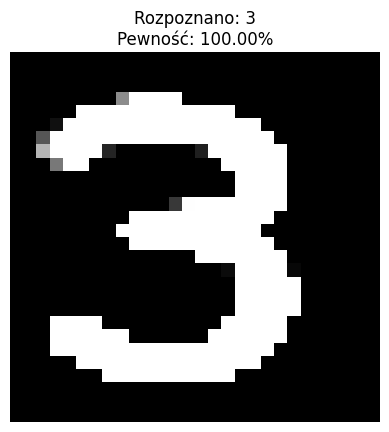

In [20]:
image_path = 'moja_cyfra.png'

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"Błąd: Nie można wczytać pliku {image_path}. Sprawdź nazwę i ścieżkę.")
else:
    img_resized = cv2.resize(img, (28, 28))
    img_inverted = cv2.bitwise_not(img_resized)
    img_normalized = img_inverted / 255.0
    img_reshaped = np.reshape(img_normalized, (1, 28, 28, 1))

    predictions = model.predict(img_reshaped)

    predicted_digit = np.argmax(predictions)
    confidence = np.max(predictions) * 100

    print(f"\nTablica prawdopodobieństw:\n{predictions}")
    print(f"Sieć neuronowa wykryła następującą cyfrę: {predicted_digit} (Pewność: {confidence:.2f}%)")

    plt.imshow(img_normalized, cmap='gray')
    plt.title(f"Rozpoznano: {predicted_digit}\nPewność: {confidence:.2f}%")
    plt.axis('off')
    plt.show()